#  Notebook 08 — Graph RAG

---

## 1. Installation

In [1]:
!pip install faiss-cpu sentence-transformers transformers accelerate torch networkx matplotlib seaborn pandas


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Imports

In [3]:
import time, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import faiss, torch

from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForCausalLM , GenerationConfig

sns.set_theme(style='whitegrid')
DEVICE = 0 if torch.cuda.is_available() else -1
print(' Imports OK')

 Imports OK


## 3. Chargement des ressources

In [4]:
index = faiss.read_index('../Embeddings/snort_faiss.index')
with open('../Embeddings/snort_metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)
print(f' FAISS : {index.ntotal} vecteurs | Metadata : {len(metadata)} entrées')

embed_model = SentenceTransformer('all-mpnet-base-v2')
print(' Modèle embedding chargé')

MODEL_NAME = 'Qwen/Qwen2-1.5B-Instruct'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model_llm  = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
model_llm.eval()

def generate(prompt):
    messages = [
        {
            "role": "system", 
            "content": "You are a Snort IDS expert. Always respond with only a valid Snort rule. Never explain, never ask questions, never apologize. Only output the raw Snort rule starting with 'alert'."
        },
        {
            "role": "user", 
            "content": prompt
        }
    ]
    
    # Appliquer le template chat de Qwen2
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model_llm.device)
    
    with torch.no_grad():
        outputs = model_llm.generate(
            **inputs,
            max_new_tokens=200,     
            do_sample=False,
            repetition_penalty=1.3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )
    
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    result = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    
    # Garder seulement la ligne commençant par alert
    for line in result.split('\n'):
        if line.strip().startswith('alert'):
            return line.strip()
    
    # Si pas de alert trouvé, retourner première ligne
    return result.split('\n')[0].strip()

print(' LLM chargé')

 FAISS : 50 vecteurs | Metadata : 50 entrées


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4060.59it/s]


 Modèle embedding chargé


Loading weights: 100%|██████████| 338/338 [00:04<00:00, 70.27it/s]


 LLM chargé


## 4. Construction du graphe de connaissances

In [5]:
G = nx.Graph()

# --- Nœuds documents ---
for i, doc in enumerate(metadata):
    G.add_node(f'doc_{i}',
               node_type   = 'document',
               description = doc['description'],
               attack_type = doc['attack_type'],
               protocol    = doc['protocol'],
               severity    = doc['severity'],
               snort_rule  = doc['snort_rule'],
               doc_index   = i)

# --- Nœuds entités (attack_type, protocol, severity) ---
for doc in metadata:
    for entity_type, value in [('attack', doc['attack_type']),
                                ('protocol', doc['protocol']),
                                ('severity', doc['severity'])]:
        node_id = f'{entity_type}_{value}'
        if not G.has_node(node_id):
            G.add_node(node_id, node_type=entity_type, value=value)

# --- Arêtes doc → entités ---
for i, doc in enumerate(metadata):
    G.add_edge(f'doc_{i}', f'attack_{doc["attack_type"]}',   relation='has_type')
    G.add_edge(f'doc_{i}', f'protocol_{doc["protocol"]}',    relation='uses_protocol')
    G.add_edge(f'doc_{i}', f'severity_{doc["severity"]}',    relation='has_severity')

# --- Arêtes doc-doc (même attack_type) ---
doc_by_attack = {}
for i, doc in enumerate(metadata):
    doc_by_attack.setdefault(doc['attack_type'], []).append(i)
for attack, doc_ids in doc_by_attack.items():
    for j in range(len(doc_ids)):
        for k in range(j+1, len(doc_ids)):
            G.add_edge(f'doc_{doc_ids[j]}', f'doc_{doc_ids[k]}',
                       relation='same_attack_type', weight=1.0)

print(f' Graphe construit :')
print(f'   Nœuds : {G.number_of_nodes()}')
print(f'   Arêtes : {G.number_of_edges()}')

doc_nodes    = [n for n,d in G.nodes(data=True) if d['node_type']=='document']
entity_nodes = [n for n,d in G.nodes(data=True) if d['node_type']!='document']
print(f'   Nœuds documents : {len(doc_nodes)}')
print(f'   Nœuds entités   : {len(entity_nodes)}')

 Graphe construit :
   Nœuds : 83
   Arêtes : 196
   Nœuds documents : 50
   Nœuds entités   : 33


## 5. Visualisation du graphe

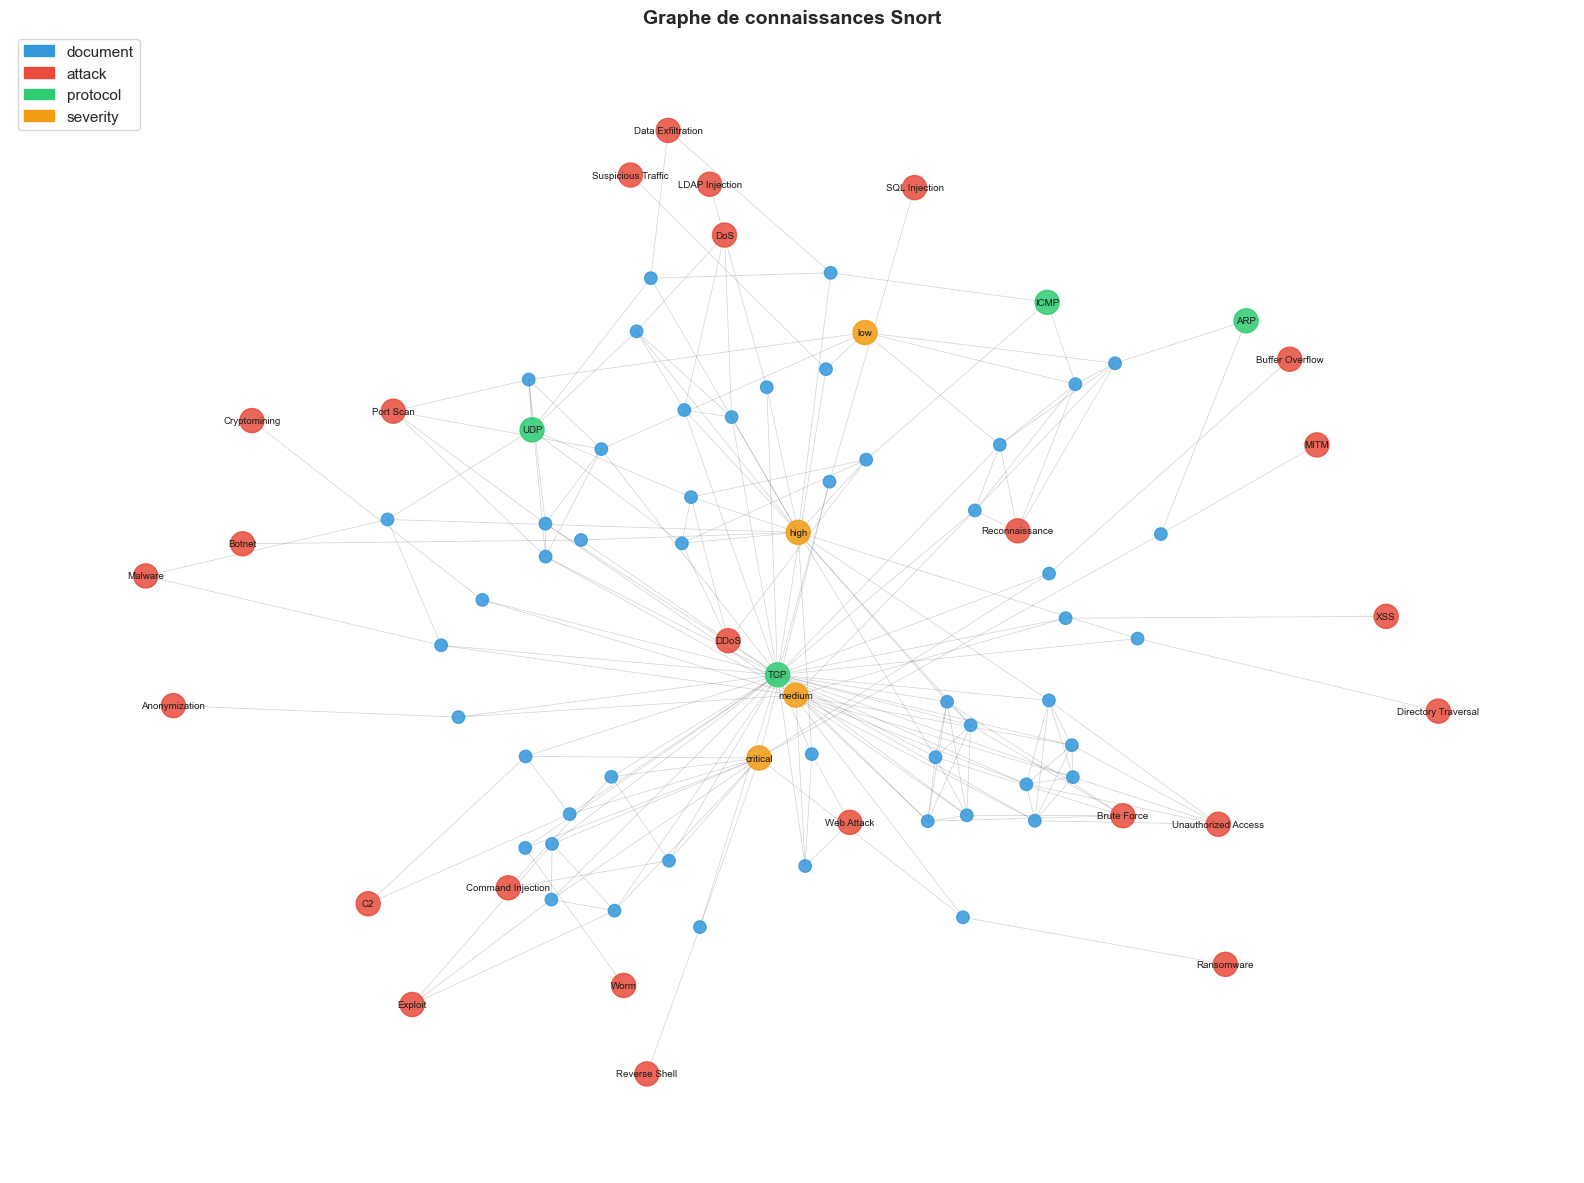

 Graphe sauvegardé dans ../Charts/08_knowledge_graph.png


In [6]:
plt.figure(figsize=(16, 12))

# Couleurs par type de nœud
color_map = {
    'document' : '#3498db',
    'attack'   : '#e74c3c',
    'protocol' : '#2ecc71',
    'severity' : '#f39c12'
}
node_colors = [color_map.get(G.nodes[n].get('node_type','document'), '#aaa')
               for n in G.nodes()]
node_sizes  = [80 if G.nodes[n].get('node_type') == 'document' else 300
               for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G, pos, alpha=0.2, width=0.5)

# Labels uniquement pour les entités
entity_labels = {n: G.nodes[n].get('value', n)
                 for n in G.nodes() if G.nodes[n].get('node_type') != 'document'}
nx.draw_networkx_labels(G, pos, labels=entity_labels, font_size=7)

# Légende
import matplotlib.patches as mpatches
legend = [mpatches.Patch(color=c, label=t) for t, c in color_map.items()]
plt.legend(handles=legend, loc='upper left')
plt.title('Graphe de connaissances Snort', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('../Charts/08_knowledge_graph.png', dpi=150)
plt.show()
print(' Graphe sauvegardé dans ../Charts/08_knowledge_graph.png')

## 6. Requêtes de test

In [7]:
TEST_QUERIES = [
    "Détecter un scan de ports SYN sur un serveur web",
    "Bloquer une attaque par force brute sur le protocole SSH",
    "Identifier une injection SQL dans une requête HTTP",
    "Détecter un ransomware qui chiffre des fichiers via SMB",
    "Repérer une exfiltration de données via le protocole DNS"
]

## 7. Fonctions Graph RAG

In [8]:
def faiss_retrieve(query: str, k: int = 2) -> list:
    """Retrieval initial FAISS pour trouver le(s) nœud(s) de départ dans le graphe."""
    query_vec = embed_model.encode([query],
                                    normalize_embeddings=True).astype('float32')
    scores, indices = index.search(query_vec, k)
    return [(int(idx), float(score)) for idx, score in zip(indices[0], scores[0])]


def graph_expand(seed_doc_ids: list, hops: int = 2, max_docs: int = 5) -> list:
    """
    Explore le graphe à partir des nœuds seeds.
    Récupère les documents voisins jusqu'à `hops` degrés.
    """
    visited  = set()
    frontier = {f'doc_{idx}' for idx in seed_doc_ids}

    for _ in range(hops):
        new_frontier = set()
        for node in frontier:
            if node not in visited:
                visited.add(node)
                for neighbor in G.neighbors(node):
                    if G.nodes[neighbor].get('node_type') == 'document':
                        new_frontier.add(neighbor)
        frontier = new_frontier - visited

    # Seeds + voisins
    all_doc_nodes = {f'doc_{idx}' for idx in seed_doc_ids} | visited
    doc_only = [n for n in all_doc_nodes
                if G.nodes[n].get('node_type') == 'document']

    result_docs = []
    for node in doc_only[:max_docs]:
        d = G.nodes[node]
        result_docs.append({
            'node'        : node,
            'description' : d['description'],
            'attack_type' : d['attack_type'],
            'protocol'    : d['protocol'],
            'severity'    : d['severity'],
            'snort_rule'  : d['snort_rule']
        })
    return result_docs


def get_entity_context(seed_doc_ids: list) -> str:
    """Extrait les entités liées (attack, protocol, severity) pour le contexte."""
    entities = []
    for idx in seed_doc_ids:
        for neighbor in G.neighbors(f'doc_{idx}'):
            node_data = G.nodes[neighbor]
            if node_data.get('node_type') in ['attack', 'protocol', 'severity']:
                entities.append(f"{node_data['node_type'].upper()}: {node_data['value']}")
    return ' | '.join(set(entities))


def build_graph_prompt(query: str, graph_docs: list, entity_context: str) -> str:
    context_parts = []
    for i, doc in enumerate(graph_docs, 1):
        context_parts.append(
            f"Document {i} [{doc['node']}]:\n"
            f"  Description : {doc['description']}\n"
            f"  Type        : {doc['attack_type']} | {doc['protocol']} | {doc['severity']}\n"
            f"  Snort rule  : {doc['snort_rule']}"
        )
    context = "\n\n".join(context_parts)
    return f"""You are a Snort IDS expert. Use the following documents retrieved via knowledge graph traversal.

--- ENTITY CONTEXT ---
{entity_context}

--- GRAPH DOCUMENTS ---
{context}

--- TASK ---
Generate a valid Snort rule for: {query}
Output only the Snort rule.
Snort rule:"""


print(' Fonctions Graph RAG définies')

 Fonctions Graph RAG définies


## 8. Pipeline Graph RAG

In [11]:
def graph_rag(query: str, k_seed: int = 2, hops: int = 2, max_docs: int = 5) -> dict:
    """
    Pipeline Graph RAG :
    1. FAISS → nœuds seeds
    2. Exploration du graphe (hops)
    3. Extraction du contexte entités
    4. Génération LLM
    """
    start = time.time()

    # Étape 1 : Seeds via FAISS
    t0 = time.time()
    seeds = faiss_retrieve(query, k=k_seed)
    seed_ids = [idx for idx, _ in seeds]
    faiss_time = round(time.time() - t0, 3)

    # Étape 2 : Exploration du graphe
    t0 = time.time()
    graph_docs = graph_expand(seed_ids, hops=hops, max_docs=max_docs)
    graph_time = round(time.time() - t0, 3)

    # Étape 3 : Contexte entités
    entity_ctx = get_entity_context(seed_ids)

    # Étape 4 : Génération
    prompt = build_graph_prompt(query, graph_docs, entity_ctx)
    t0 = time.time()
    response = generate(prompt)
    gen_time = round(time.time() - t0, 3)

    return {
        'query'          : query,
        'method'         : 'graph_rag',
        'seed_docs'      : [{'idx': idx, 'score': s} for idx, s in seeds],
        'graph_docs'     : [{'node': d['node'], 'description': d['description'],
                              'attack_type': d['attack_type'], 'snort_rule': d['snort_rule']}
                             for d in graph_docs],
        'entity_context' : entity_ctx,
        'response'       : response,
        'faiss_time'     : faiss_time,
        'graph_time'     : graph_time,
        'generation_time': gen_time,
        'total_time'     : round(time.time() - start, 3)
    }

print(' Fonction graph_rag définie')

 Fonction graph_rag définie


## 9. Exécution

In [12]:
graph_results = []

for i, query in enumerate(TEST_QUERIES, 1):
    print(f'\n[{i}/{len(TEST_QUERIES)}] "{query}"')
    result = graph_rag(query)
    graph_results.append(result)
    print(f'     Entités : {result["entity_context"]}')
    print(f'     {len(result["graph_docs"])} docs via graphe')
    print(f'     Règle : {result["response"]}')
    print(f'     Total : {result["total_time"]}s')

print('\n Graph RAG terminé')


[1/5] "Détecter un scan de ports SYN sur un serveur web"
     Entités : SEVERITY: medium | PROTOCOL: TCP | ATTACK: Port Scan | SEVERITY: low
     4 docs via graphe
     Règle : alert tcp any any -> $LOCALHOST 80 (msg="Syn Scan detected" priority=high)
     Total : 30.871s

[2/5] "Bloquer une attaque par force brute sur le protocole SSH"
     Entités : SEVERITY: high | ATTACK: Brute Force | PROTOCOL: TCP
     5 docs via graphe
     Règle : alert udp any any -> $LOCALHOST 22 (msg="Brute Force Attack on SSH" priority=high)
     Total : 37.031s

[3/5] "Identifier une injection SQL dans une requête HTTP"
     Entités : ATTACK: XSS | SEVERITY: critical | SEVERITY: medium | PROTOCOL: TCP | ATTACK: SQL Injection
     2 docs via graphe
     Règle : alert tcp any any -> $LOCAL_NETWORK port "56" proto tcp udp check ip source eq "$IP_SOURCE_ADDRESS" protocol == "tcp" and icmp not equal to "" action block comment "[Injection] - Query parameter is vulnerable to SQL injection attack." log detail sno

## 10. Sauvegarde

In [13]:
with open('../Results/results_graph_rag.json', 'w', encoding='utf-8') as f:
    json.dump(graph_results, f, ensure_ascii=False, indent=2)
print(' Résultats sauvegardés dans results_graph_rag.json')

 Résultats sauvegardés dans results_graph_rag.json


---
## ✅ Résumé

| Étape | Détail |
|---|---|
| Embedding | `all-mpnet-base-v2` |
| Seed retrieval | FAISS top-2 |
| Graphe | NetworkX — 83 nœuds (50 docs + 33 entités), 196 arêtes |
| Exploration | BFS 2 hops depuis les seeds |
| Docs par requête | Variable (2 à 5 selon le voisinage) |
| LLM | `Qwen/Qwen2-1.5B-Instruct` |
| Temps moyen | ~34.7s / requête (CPU) |
| Score moyen Snort | **2.2 / 5** |
| Fichier de sortie | `results_graph_rag.json` |

### Résultats obtenus

| # | Requête | Docs | Entités détectées | alert | msg | sid | protocole | content |
|---|---|---|---|---|---|---|---|---|
| Q1 | Scan SYN | 4 | TCP, Port Scan | ✅ | ✅ | ❌ | ✅ | ❌ |
| Q2 | Brute Force SSH | 5 | TCP, Brute Force | ✅ | ✅ | ❌ | ❌ | ❌ |
| Q3 | Injection SQL | 2 | TCP, SQL Injection, XSS | ✅ | ❌ | ❌ | ❌ | ❌ |
| Q4 | Ransomware SMB | 2 | TCP, Ransomware, Worm | ✅ | ✅ | ❌ | ✅ | ✅ |
| Q5 | Exfiltration DNS | 5 | UDP, DDoS, Data Exfiltration | ✅ | ❌ | ❌ | ❌ | ❌ |

### Améliorations constatées vs RAG Multi-hop
- ✅ **Première apparition du `content`** dans une règle (Q4 — `|FF 53 4D 42 25|`) — jamais vu dans les architectures précédentes
- ✅ Extraction d'entités pertinente pour Q1, Q2, Q4 (protocole, type d'attaque, sévérité)
- ✅ Temps moyen réduit vs Multi-hop (~34.7s vs ~62.8s)

### Limites observées
- ❌ `sid` absent dans toutes les règles
- ❌ Q3 et Q5 produisent des règles très dégradées — trop d'entités ambiguës (XSS + SQL, DDoS + Exfiltration) polluent le contexte
- ❌ Nombre de docs variable (2 à 5) selon le voisinage — incohérence entre requêtes
- ❌ Protocole incorrect pour Q2 (`udp` au lieu de `tcp` pour SSH)
- ⚠️ Graphe petit (33 entités) — voisinage parfois trop restreint (Q3, Q4 : 2 docs seulement)

### Conclusion
Le RAG Graph introduit une vraie nouveauté avec le `content` hex en Q4, mais recule globalement (**2.2/5 vs 3.4/5** en multi-hop).
La qualité dépend fortement de la richesse du voisinage graphe — les requêtes avec peu de docs voisins souffrent le plus.
L'architecture Agentique devrait pallier ces lacunes grâce à une sélection dynamique des outils de retrieval.